# EE-411 Lottery Ticket Hypothesis - Experiment Resnet-18 + Iterative + Random Init +Learning Rate = 0.01

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.11]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_iterative_random_init_LR_0.01"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_iterative_random_init_LR_0.01_20260111_205802
Results will be saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [3]:
# CIFAR-10 Data Loading


# Define transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # New ! Crucial for CIFAR-10 
    transforms.RandomHorizontalFlip(),     # New ! Crucial for generalization 
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])


# ============================================================================
# 2. Download and Load Datasets (Twice!)
# ============================================================================

# transform_train
train_set_augmented = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train  # <--- Augmented data
)

# transform_test
train_set_clean = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_test   # <--- Clean data
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)



# ============================================================================
# 3. Split Train/Val using Indices
# ============================================================================
# Make sure it's able to reproduce the same split every time
num_train = len(train_set_augmented) # 50000
indices = list(range(num_train))
split = 45000
seed = 42 

np.random.seed(seed)
np.random.shuffle(indices)

train_idx = indices[:split]
val_idx = indices[split:]

# train_dataset
train_dataset = Subset(train_set_augmented, train_idx)
# val_dataset construction using clean data
val_dataset   = Subset(train_set_clean, val_idx)


# ============================================================================
# 4. Create Data Loaders
# ============================================================================
# Create data loaders
# batch_size = 60  # From paper
batch_size = 128  # Paper uses 128 for ResNet-18

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

# ============================================================================
# 5. Verify & Config Check
# ============================================================================

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# Automatic Epochs Recommendation
iterations_needed = 30000
steps_per_epoch = len(train_loader)
recommended_epochs = int(np.ceil(iterations_needed / steps_per_epoch))

print(f"\n[Config Check]")
print(f"To reach {iterations_needed} iterations with batch size {batch_size}:")
print(f"You should set EPOCHS >= {recommended_epochs}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 352

[Config Check]
To reach 30000 iterations with batch size 128:
You should set EPOCHS >= 86


## 3. Model Definition

**TODO: Define your model here**

In [4]:
# ResNet18 for CIFAR-10
import copy
import torch
import torch.nn as nn
# from torchvision.models import resnet18
import torch.nn.functional as F
import torch.nn.init as init



# # ResNet-20 for CIFAR-10 (Kaiming He, used in the paper)
# def _weights_init(m):
#     """
#     Kaiming Initialization (He Initialization) as used in the paper.
#     """
#     if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
#         init.kaiming_normal_(m.weight)

def _weights_init(m):
    """
    Paper uses Gaussian Glorot (Xavier Normal) initialization.
    """
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        # 论文使用的是 Gaussian Glorot (Xavier Normal)
        init.xavier_normal_(m.weight)
        # 如果有 bias，通常初始化为 0 (虽然 ResNet 的 Conv 通常没有 bias)
        if m.bias is not None:
            init.constant_(m.bias, 0)

            

class LambdaLayer(nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = nn.Sequential() # named as "downsample" as pruning.py
        if stride != 1 or in_planes != planes:
            # Paper Option A: Zero-padding for shortcut
            self.downsample = LambdaLayer(lambda x:
                                        F.pad(x[:, :, ::2, ::2], (0, 0, 0, 0, planes//4, planes//4), "constant", 0))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.downsample(x)
        out = F.relu(out)
        return out

class ResNet20_CIFAR10(nn.Module):
    def __init__(self):
        super(ResNet20_CIFAR10, self).__init__()
        self.in_planes = 16
        
        # ResNet-20: 3 layers * 3 blocks * 2 convs + 1st conv + 1 linear = 20 layers
        num_blocks = [3, 3, 3] 

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.layer1 = self._make_layer(BasicBlock, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 64, num_blocks[2], stride=2)
        
        self.linear = nn.Linear(64, 10)
        
        # Apply initialization
        self.apply(_weights_init)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size()[3])
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out



# Create model instance
# model = ResNet18_CIFAR10().to(device)
model = ResNet20_CIFAR10().to(device)
initial_weights_state = copy.deepcopy(model.state_dict())
init_weights_path = os.path.join(ckpt_dir, f"initial_weights_theta0_{run_id}.pth")
torch.save(initial_weights_state, init_weights_path)
print(f"Initial weights saved to: {init_weights_path}")

# Print model info
total_params = count_parameters(model)
print(f"Model: ResNet20_CIFAR10")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Initial weights saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/initial_weights_theta0_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth
Model: ResNet20_CIFAR10
Total parameters: 269,722

Model architecture:
ResNet20_CIFAR10(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), pad

## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [5]:
# Training configuration (from paper)
# Adjust these based on your model!
     
learning_rate = 0.01 # Paper recommends 0.1 (or 0.03 with warmup)
epochs = 86  

# Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=learning_rate,             # Paper recommends 0.1 for constant, or 0.03 with warmup
    momentum=0.9, 
    weight_decay=1e-4   # Helps prevent overfitting
)

# Paper: Divide LR by 10 at 20k and 25k iterations
# 20,000 / 352 ≈ 57 epochs
# 25,000 / 352 ≈ 71 epochs
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, 
    milestones=[57, 71], 
    gamma=0.01
)

# --- Dynamic Print ---
optimizer_name = optimizer.__class__.__name__
current_lr = optimizer.param_groups[0]['lr']

print(f"Training configuration:")
print(f"  Optimizer: {optimizer_name}") # Dynamic!
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

test_loss, test_accuracy = predict(model, test_loader, device)

Training configuration:
  Optimizer: SGD
  Learning rate: 0.01
  Epochs: 86
  Batch size: 128

Starting training...

Test set: Avg. loss: 2.8741, Accuracy: 1049/10000 (10%)


In [ ]:
# # Train using shared training_utils
# losses = fit(
#     model=model,
#     train_dataloader=train_loader,
#     optimizer=optimizer,
#     epochs=epochs,
#     device=device,
#     scheduler=scheduler  # New! Don't forget to pass the scheduler!
# )

# # Evaluate on test set
# test_loss, test_accuracy = predict(model, test_loader, device)

# print(f"\n{'='*60}")
# print(f"Baseline Results")
# print(f"{'='*60}")
# print(f"Test Accuracy: {test_accuracy:.2f}%")
# print(f"Test Loss: {test_loss:.4f}")

### Visualize Training

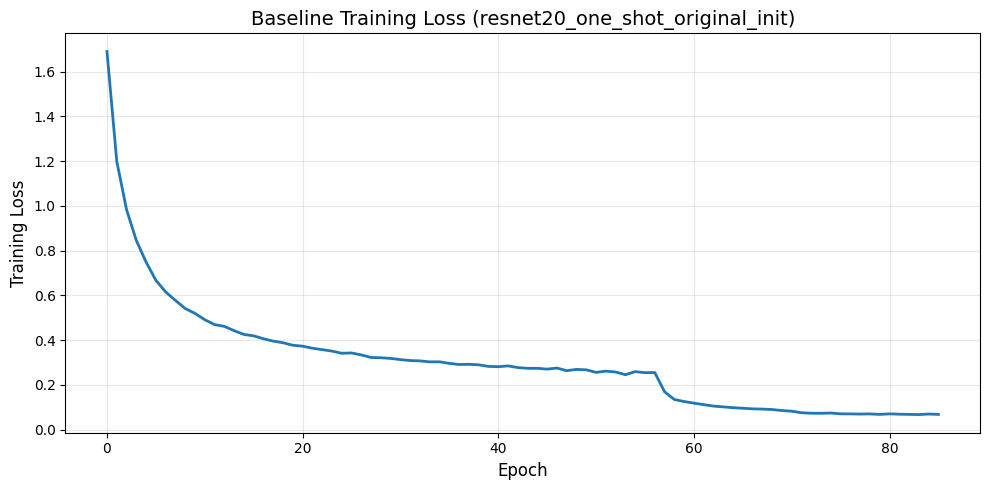

Loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_resnet20_one_shot_original_init_20260110_215316.png


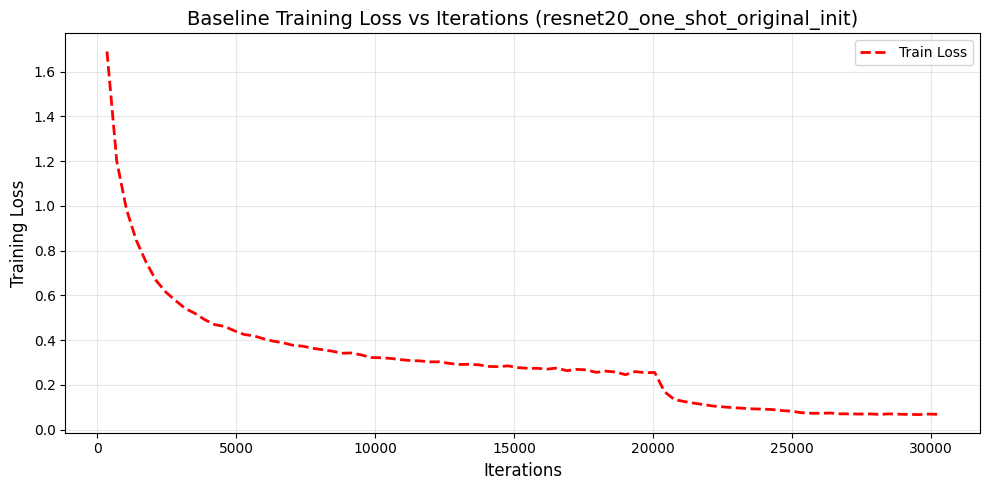

Iteration-based loss figure saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/figures/baseline_loss_iter_resnet20_one_shot_original_init_20260110_215316.png


In [ ]:
# iterations_per_epoch = len(train_loader)
# # ================= Drawing Figure 1: X-axis = Epochs =================

# plt.figure(figsize=(10, 5))
# plt.plot(losses, linewidth=2)
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()

# # Save with run_id
# loss_fig_path = os.path.join(fig_dir, f"baseline_loss_{run_id}.png")
# plt.savefig(loss_fig_path, dpi=150)
# plt.show()

# print(f"Loss figure saved to: {loss_fig_path}")

# # ================= Drawing Figure 2: X-axis = Iterations =================
# iterations_x = [i * iterations_per_epoch for i in range(1, len(losses) + 1)]

# plt.figure(figsize=(10, 5))
# plt.plot(iterations_x, losses, linewidth=2, color='red', linestyle='--', label='Train Loss')
# plt.xlabel('Iterations', fontsize=12)
# plt.ylabel('Training Loss', fontsize=12)
# plt.title(f'Baseline Training Loss vs Iterations ({model_name})', fontsize=14)
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()

# # Save Iteration Figure
# loss_fig_path_iter = os.path.join(fig_dir, f"baseline_loss_iter_{run_id}.png")
# plt.savefig(loss_fig_path_iter, dpi=150)
# plt.show()
# print(f"Iteration-based loss figure saved to: {loss_fig_path_iter}")

### Save Baseline Model

In [ ]:
# # --- Save Baseline Model ---
# # Save with the unique run_id in the filename
# baseline_path = os.path.join(ckpt_dir, f"baseline_{run_id}.pth")

# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'test_accuracy': test_accuracy,
#     'test_loss': test_loss,
#     'epochs': epochs,
#     'config': {
#         'optimizer': optimizer_name,
#         'lr': current_lr
#     }
# }, baseline_path)

# print(f"Baseline model saved to: {baseline_path}")

Baseline model saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/checkpoints/baseline_resnet20_one_shot_original_init_20260110_215316.pth


## 5. Pruning Experiments

### 5.1 Iterative Pruning

Run the main pruning experiment from the paper.

In [7]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18'

# pruning_config = get_pruning_config('conv2')  # Change this for your model
pruning_config = get_pruning_config('resnet18')

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")


Pruning Configuration:
  prune_rate_conv: 0.2
  prune_rate_fc: 0.0
  pruning_strategy: global
  description: ResNet-18 for CIFAR-10


In [8]:
# Create fresh model for pruning
# model_pruning = Conv2().to(device)  # Replace with your model
# model_pruning = ResNet18_CIFAR10().to(device) 
model_pruning = ResNet20_CIFAR10().to(device) 

epochs_per_round = 86  # (30k iter / 352 steps)

results = iterative_pruning(
    model=model_pruning,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={'lr': 0.01, 'momentum': 0.9, 'weight_decay': 1e-4},
    device=device,
    config=pruning_config,
    n_rounds=15,          # 15 rounds to match paper's ~90% sparsity
    epochs_per_round=epochs_per_round,  # each 30k iterations
    verbose=True
)

print("\nPruning experiment complete!")

iterative_path = os.path.join(ckpt_dir, f"iterative_pruning_results_{run_id}.pth")
torch.save({
    'results': results,
    'config': pruning_config,
    'initial_weights_state': initial_weights_state
}, iterative_path)
print(f"Iterative pruning results saved to: {iterative_path}")

Starting Iterative Pruning
Initial parameters: 269,722
Pruning strategy: global
Conv prune rate: 20.0%
FC prune rate: 0.0%

Round 1/15
Scheduler enabled: MultiStepLR at epochs 56 and 71
Epoch 01 | Train Loss: 1.6298 | Val Loss: 1.6929 | Val Acc: 42.80% | Test Acc: 42.74%
Epoch 02 | Train Loss: 1.1979 | Val Loss: 1.1767 | Val Acc: 58.20% | Test Acc: 58.82%
Epoch 03 | Train Loss: 1.0140 | Val Loss: 1.0756 | Val Acc: 62.44% | Test Acc: 62.02%
Epoch 04 | Train Loss: 0.8824 | Val Loss: 1.1538 | Val Acc: 64.50% | Test Acc: 64.21%
Epoch 05 | Train Loss: 0.7984 | Val Loss: 1.3474 | Val Acc: 60.54% | Test Acc: 60.25%
Epoch 06 | Train Loss: 0.7247 | Val Loss: 0.7866 | Val Acc: 72.98% | Test Acc: 73.18%
Epoch 07 | Train Loss: 0.6694 | Val Loss: 0.7604 | Val Acc: 74.16% | Test Acc: 73.91%
Epoch 08 | Train Loss: 0.6299 | Val Loss: 0.6762 | Val Acc: 77.52% | Test Acc: 77.26%
Epoch 09 | Train Loss: 0.5956 | Val Loss: 0.7268 | Val Acc: 76.10% | Test Acc: 76.52%


Epoch 10/86: 100%|██████████| 352/352 [00:05<00:00, 63.60it/s]


Epoch 10 | Train Loss: 0.5678 | Val Loss: 0.7059 | Val Acc: 77.16% | Test Acc: 77.46%
Epoch 11 | Train Loss: 0.5384 | Val Loss: 0.6936 | Val Acc: 77.52% | Test Acc: 77.97%
Epoch 12 | Train Loss: 0.5189 | Val Loss: 0.7411 | Val Acc: 75.32% | Test Acc: 76.42%
Epoch 13 | Train Loss: 0.4982 | Val Loss: 0.6267 | Val Acc: 79.32% | Test Acc: 79.27%
Epoch 14 | Train Loss: 0.4875 | Val Loss: 0.5832 | Val Acc: 81.12% | Test Acc: 81.44%
Epoch 15 | Train Loss: 0.4600 | Val Loss: 0.5709 | Val Acc: 80.84% | Test Acc: 81.74%
Epoch 16 | Train Loss: 0.4493 | Val Loss: 0.6665 | Val Acc: 78.58% | Test Acc: 78.39%
Epoch 17 | Train Loss: 0.4412 | Val Loss: 0.5527 | Val Acc: 81.98% | Test Acc: 82.08%
Epoch 18 | Train Loss: 0.4194 | Val Loss: 0.6307 | Val Acc: 80.58% | Test Acc: 80.07%
Epoch 19 | Train Loss: 0.4109 | Val Loss: 0.5584 | Val Acc: 81.20% | Test Acc: 81.42%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 62.43it/s]


Epoch 20 | Train Loss: 0.3974 | Val Loss: 0.5679 | Val Acc: 81.76% | Test Acc: 81.86%
Epoch 21 | Train Loss: 0.3881 | Val Loss: 0.5198 | Val Acc: 82.86% | Test Acc: 82.94%
Epoch 22 | Train Loss: 0.3778 | Val Loss: 0.6650 | Val Acc: 79.14% | Test Acc: 79.27%
Epoch 23 | Train Loss: 0.3643 | Val Loss: 0.5033 | Val Acc: 83.20% | Test Acc: 83.80%
Epoch 24 | Train Loss: 0.3577 | Val Loss: 0.6092 | Val Acc: 80.92% | Test Acc: 80.71%
Epoch 25 | Train Loss: 0.3532 | Val Loss: 0.5582 | Val Acc: 82.68% | Test Acc: 81.91%
Epoch 26 | Train Loss: 0.3421 | Val Loss: 0.5215 | Val Acc: 83.38% | Test Acc: 83.47%
Epoch 27 | Train Loss: 0.3366 | Val Loss: 0.5066 | Val Acc: 83.84% | Test Acc: 83.91%
Epoch 28 | Train Loss: 0.3226 | Val Loss: 0.4511 | Val Acc: 85.46% | Test Acc: 85.45%
Epoch 29 | Train Loss: 0.3182 | Val Loss: 0.5198 | Val Acc: 82.42% | Test Acc: 82.50%


...

Epoch 60 | Train Loss: 0.2701 | Val Loss: 0.3877 | Val Acc: 87.18% | Test Acc: 87.37%
Epoch 61 | Train Loss: 0.2685 | Val Loss: 0.3903 | Val Acc: 87.06% | Test Acc: 87.41%
Epoch 62 | Train Loss: 0.2683 | Val Loss: 0.3867 | Val Acc: 87.22% | Test Acc: 87.28%
Epoch 63 | Train Loss: 0.2690 | Val Loss: 0.3905 | Val Acc: 87.30% | Test Acc: 87.44%
Epoch 64 | Train Loss: 0.2635 | Val Loss: 0.3886 | Val Acc: 87.38% | Test Acc: 87.31%
Epoch 65 | Train Loss: 0.2618 | Val Loss: 0.3937 | Val Acc: 87.08% | Test Acc: 87.36%
Epoch 66 | Train Loss: 0.2626 | Val Loss: 0.3931 | Val Acc: 87.04% | Test Acc: 87.28%
Epoch 67 | Train Loss: 0.2639 | Val Loss: 0.3903 | Val Acc: 87.52% | Test Acc: 87.29%
Epoch 68 | Train Loss: 0.2636 | Val Loss: 0.3894 | Val Acc: 87.18% | Test Acc: 87.33%
Epoch 69 | Train Loss: 0.2634 | Val Loss: 0.3918 | Val Acc: 87.34% | Test Acc: 87.36%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 61.99it/s]


Epoch 70 | Train Loss: 0.2616 | Val Loss: 0.3892 | Val Acc: 87.42% | Test Acc: 87.43%
Epoch 71 | Train Loss: 0.2585 | Val Loss: 0.3905 | Val Acc: 87.28% | Test Acc: 87.61%
 -> Scheduler Step! Current LR: 0.0001
   [Tracker] 🚩 Early Stop Condition at Iter 25344 (Epoch 72, Test Acc: 87.53%)
Epoch 72 | Train Loss: 0.2550 | Val Loss: 0.3898 | Val Acc: 87.36% | Test Acc: 87.53%
 -> Scheduler Step! Current LR: 0.0001
Epoch 73 | Train Loss: 0.2589 | Val Loss: 0.3885 | Val Acc: 87.56% | Test Acc: 87.45%
Epoch 74 | Train Loss: 0.2562 | Val Loss: 0.3908 | Val Acc: 87.36% | Test Acc: 87.49%
Epoch 75 | Train Loss: 0.2578 | Val Loss: 0.3879 | Val Acc: 87.30% | Test Acc: 87.39%
Epoch 76 | Train Loss: 0.2556 | Val Loss: 0.3885 | Val Acc: 87.68% | Test Acc: 87.66%
Epoch 77 | Train Loss: 0.2560 | Val Loss: 0.3871 | Val Acc: 87.50% | Test Acc: 87.47%
Epoch 78 | Train Loss: 0.2561 | Val Loss: 0.3867 | Val Acc: 87.48% | Test Acc: 87.56%
Epoch 79 | Train Loss: 0.2513 | Val Loss: 0.3881 | Val Acc: 87.36% | 

Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 62.30it/s]


Epoch 80 | Train Loss: 0.2551 | Val Loss: 0.3916 | Val Acc: 87.30% | Test Acc: 87.46%
Epoch 81 | Train Loss: 0.2513 | Val Loss: 0.3887 | Val Acc: 87.30% | Test Acc: 87.54%
Epoch 82 | Train Loss: 0.2571 | Val Loss: 0.3913 | Val Acc: 87.62% | Test Acc: 87.43%
Epoch 83 | Train Loss: 0.2544 | Val Loss: 0.3873 | Val Acc: 87.58% | Test Acc: 87.55%
Epoch 84 | Train Loss: 0.2526 | Val Loss: 0.3858 | Val Acc: 87.58% | Test Acc: 87.50%
Epoch 85 | Train Loss: 0.2581 | Val Loss: 0.3891 | Val Acc: 87.26% | Test Acc: 87.50%
Epoch 86 | Train Loss: 0.2536 | Val Loss: 0.3878 | Val Acc: 87.48% | Test Acc: 87.42%

Round 15 Results:
  Test Accuracy: 87.42%
  Remaining Parameters: 11,444.0 (4.24%)

Iterative Pruning Complete!

Pruning experiment complete!
Iterative pruning results saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth


In [9]:
# Extract data for plotting
# Iterative pruning
rounds = [r['round'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
remaining_params_pct = [r['remaining_params_pct'] for r in results]
remaining_params = [r['remaining_params'] for r in results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)


Pruning Results Summary
Round    Params %     Params          Test Acc %  
----------------------------------------------------------------------
1        80.15        216,183.0       88.92       
2        64.27        173,351.0       88.76       
3        51.57        139,086.0       89.13       
4        41.40        111,674.0       89.46       
5        33.27        89,744.0        89.27       
6        26.77        72,200.0        89.15       
7        21.56        58,165.0        89.57       
8        17.40        46,937.0        89.04       
9        14.07        37,955.0        89.10       
10       11.41        30,769.0        89.35       
11       9.28         25,020.0        89.00       
12       7.57         20,421.0        89.14       
13       6.21         16,742.0        88.45       
14       5.12         13,799.0        88.28       
15       4.24         11,444.0        87.42       


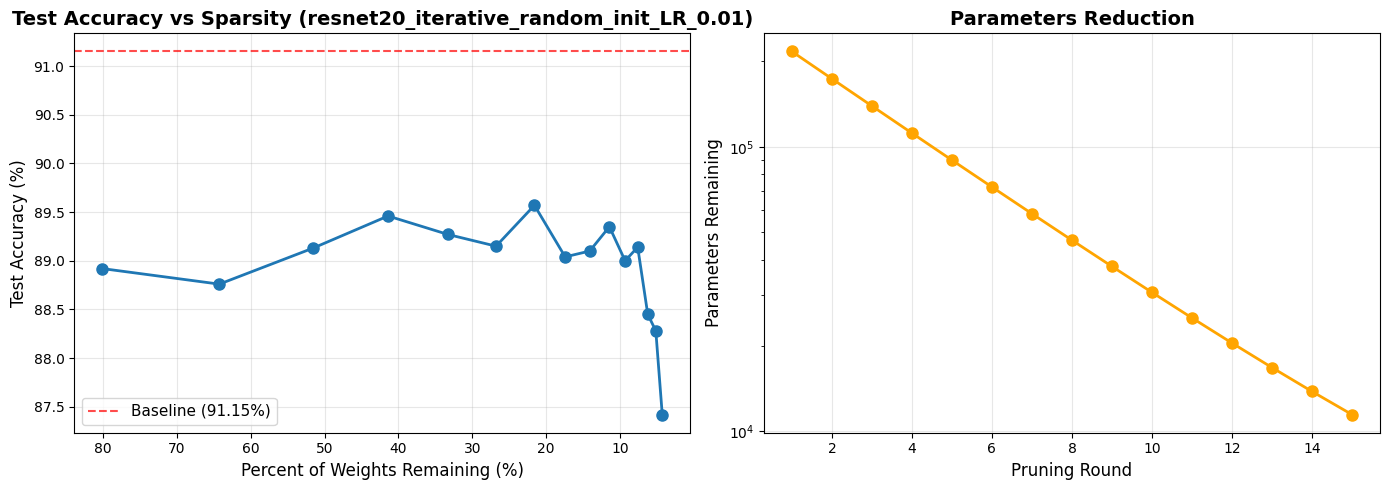

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/figures/Iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.png


In [12]:
# --- Visualize ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)

# Robust baseline line handling (CPU/GPU compatible)
baseline_acc_val = 91.15
# baseline_acc_val = test_accuracy.item() if isinstance(test_accuracy, torch.Tensor) else test_accuracy
ax1.axhline(y=baseline_acc_val, color='r', linestyle='--', label=f'Baseline ({baseline_acc_val:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({model_name})', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis() 

# Plot 2: Params Reduction
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') # Log scale is great for pruning

plt.tight_layout()

# Save Pruning Figure
pruning_fig_path = os.path.join(fig_dir, f"Iterative_pruning_results_{run_id}.png")
plt.savefig(pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {pruning_fig_path}")

In [13]:
# Identify winning tickets
baseline_accuracy = 91.15
# baseline_accuracy = test_accuracy
winning_tickets = []

for r in results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets:
    best_ticket = min(winning_tickets, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 3 Winning Tickets!
Baseline Accuracy: 91.15%

Winning Tickets (accuracy >= 89.33%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------
4        58.6         111,674.0       89.46       
7        78.4         58,165.0        89.57       
10       88.6         30,769.0        89.35       

Best Winning Ticket:
  Round: 10
  Sparsity: 88.6%
  Parameters: 30,769.0
  Accuracy: 89.35%


### 5.2 Random Init

In [16]:
import torch
import os
import copy
# 假设 random_reinit_pruning 在当前文件的作用域内，或者从模块导入
# from shared.pruning import random_reinit_pruning 

# ==========================================
# 0. Setup & Configuration
# ==========================================
# 确保你的 ResNet20_CIFAR10 类已经定义或导入
# 确保 device, train_loader, test_loader 已经定义

# load_path = "../../results/resnet20_iterative_random_init_20260111_011546/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_20260111_011546.pth"
load_path = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"

if not os.path.exists(load_path):
    raise FileNotFoundError(f"File not found: {load_path}")

# ==========================================
# 1. Load Iterative Pruning Results
# ==========================================
checkpoint_data = torch.load(load_path)
iterative_results = checkpoint_data['results']
loaded_config = checkpoint_data.get('config', {}) # 获取保存的配置

print(f"Successfully loaded results for {len(iterative_results)} stages.")

# ==========================================
# 2. Extract Hyperparameters (Critical for Matching!)
# ==========================================
# 尝试从 config 中恢复参数，如果找不到则使用默认值
# 这样能保证你的 Random Init 用的 LR 和 Epochs 与 Winning Ticket 完全一致
# saved_lr = loaded_config.get('optimizer_kwargs', {}).get('lr', 0.1) # 默认0.1，但建议检查
# saved_epochs = loaded_config.get('epochs_per_round', 86)           # 默认86

saved_lr = 0.01  # Manually set to match the experiment
saved_epochs = 86

print("\n" + "="*50)
print(f"Detected Hyperparameters from Checkpoint:")
print(f"  Learning Rate: {saved_lr}")
print(f"  Epochs per round: {saved_epochs}")
print("="*50 + "\n")

Successfully loaded results for 15 stages.

Detected Hyperparameters from Checkpoint:
  Learning Rate: 0.01
  Epochs per round: 86



In [ ]:
random_init_results = []

# ==========================================
# 3. Iterate through each Mask and Train
# ==========================================
print("Starting Random Init control experiment...")

for i, res in enumerate(iterative_results):
    # Retrieve mask and sparsity information
    mask = res['mask']
    sparsity = res['remaining_params_pct']
    
    # Skip if Mask is None (Level 0 / Baseline)
    # 也可以跑，但通常 Random Init 的 Baseline 就是普通的训练，没必要重复跑，除非为了验证随机性
    if mask is None:
        continue
        
    print(f"\n[{i+1}/{len(iterative_results)}] Testing Random Init with Sparsity: {sparsity:.2f}%")
    
    # Instantiate a FRESH model every time to ensure clean state
    # 每次都创建一个全新的模型实例，比 deepcopy 更保险
    model_instance = ResNet20_CIFAR10().to(device)
    
    # !!! CRITICAL STEP !!!
    # 调用我们修改过的 random_reinit_pruning
    run_result = random_reinit_pruning(
        model=model_instance, 
        train_loader=train_loader,
        test_loader=test_loader,
        val_loader=val_loader,     # [New] 加上这个参数 (用 test_loader 充当 val)
        optimizer_class=torch.optim.SGD,
        # [Critical] 使用从 config 读取的参数
        optimizer_kwargs={'lr': saved_lr, 'momentum': 0.9, 'weight_decay': 1e-4}, 
        device=device,
        mask=mask,        
        epochs=saved_epochs,  # [Critical] 必须一致
        verbose=True      
    )
    
    # Append minimal info needed for plotting
    # 我们修改过的函数已经返回了 'test_accuracy', 'remaining_params_pct' 等
    # 这里只需补充 round 信息
    run_result['round'] = res['round']
    
    random_init_results.append(run_result)

print("\nAll Random Init experiments completed!")

# ==========================================
# 4. Save Random Init Results
# ==========================================
# 构造保存路径，通常放在和 load_path 同级目录下
# save_dir = os.path.dirname(load_path)
random_reinit_results_path = os.path.join(ckpt_dir, f"random_init_results__{run_id}.pth")

torch.save({
    'results': random_init_results,
    'config': loaded_config # 保存同样的 config 方便追溯
}, random_reinit_results_path)

print(f"✅ Random Init results saved to: {random_reinit_results_path}")

Starting Random Init control experiment...

[1/15] Testing Random Init with Sparsity: 80.15%

Starting Random Reinit Control Experiment
Sparsity Level: 80.15% weights remaining
Scheduler enabled: MultiStepLR at epochs 56 and 71
Epoch 01 | Train Loss: 1.6143 | Val Loss: 1.5350 | Val Acc: 46.34% | Test Acc: 47.46%
Epoch 02 | Train Loss: 1.2374 | Val Loss: 1.1193 | Val Acc: 59.74% | Test Acc: 60.39%
Epoch 03 | Train Loss: 1.0370 | Val Loss: 1.2350 | Val Acc: 58.60% | Test Acc: 58.57%
Epoch 04 | Train Loss: 0.9033 | Val Loss: 0.9943 | Val Acc: 64.98% | Test Acc: 65.47%
Epoch 05 | Train Loss: 0.8156 | Val Loss: 1.0667 | Val Acc: 65.54% | Test Acc: 66.54%
Epoch 06 | Train Loss: 0.7477 | Val Loss: 0.9508 | Val Acc: 70.02% | Test Acc: 70.45%
Epoch 07 | Train Loss: 0.6886 | Val Loss: 0.8537 | Val Acc: 72.00% | Test Acc: 72.81%
Epoch 08 | Train Loss: 0.6476 | Val Loss: 0.9522 | Val Acc: 69.32% | Test Acc: 70.11%
Epoch 09 | Train Loss: 0.6118 | Val Loss: 1.2200 | Val Acc: 65.36% | Test Acc: 65.63

Epoch 10/86: 100%|██████████| 352/352 [00:06<00:00, 51.83it/s]


Epoch 10 | Train Loss: 0.5825 | Val Loss: 0.6665 | Val Acc: 77.78% | Test Acc: 77.59%
Epoch 11 | Train Loss: 0.5612 | Val Loss: 0.8396 | Val Acc: 74.24% | Test Acc: 74.37%
Epoch 12 | Train Loss: 0.5297 | Val Loss: 0.6657 | Val Acc: 78.02% | Test Acc: 77.68%
Epoch 13 | Train Loss: 0.5081 | Val Loss: 0.8862 | Val Acc: 73.62% | Test Acc: 73.63%
Epoch 14 | Train Loss: 0.4934 | Val Loss: 0.6129 | Val Acc: 80.16% | Test Acc: 79.83%
Epoch 15 | Train Loss: 0.4735 | Val Loss: 0.7745 | Val Acc: 76.14% | Test Acc: 76.10%
Epoch 16 | Train Loss: 0.4557 | Val Loss: 0.6183 | Val Acc: 80.18% | Test Acc: 79.86%
Epoch 17 | Train Loss: 0.4431 | Val Loss: 0.6611 | Val Acc: 78.10% | Test Acc: 78.65%
Epoch 18 | Train Loss: 0.4296 | Val Loss: 0.6197 | Val Acc: 79.74% | Test Acc: 80.07%
Epoch 19 | Train Loss: 0.4189 | Val Loss: 0.5615 | Val Acc: 81.70% | Test Acc: 81.90%


Epoch 20/86: 100%|██████████| 352/352 [00:05<00:00, 58.68it/s]


Epoch 20 | Train Loss: 0.4092 | Val Loss: 0.6267 | Val Acc: 79.56% | Test Acc: 80.29%
Epoch 21 | Train Loss: 0.3956 | Val Loss: 0.5532 | Val Acc: 81.98% | Test Acc: 82.32%
Epoch 22 | Train Loss: 0.3845 | Val Loss: 0.5441 | Val Acc: 82.58% | Test Acc: 82.57%
Epoch 23 | Train Loss: 0.3808 | Val Loss: 0.5452 | Val Acc: 82.30% | Test Acc: 82.46%
Epoch 24 | Train Loss: 0.3682 | Val Loss: 0.5785 | Val Acc: 82.20% | Test Acc: 81.02%
Epoch 25 | Train Loss: 0.3605 | Val Loss: 0.5147 | Val Acc: 83.66% | Test Acc: 83.66%
Epoch 26 | Train Loss: 0.3550 | Val Loss: 0.5368 | Val Acc: 82.96% | Test Acc: 82.95%
Epoch 27 | Train Loss: 0.3404 | Val Loss: 0.5479 | Val Acc: 82.94% | Test Acc: 82.53%
Epoch 28 | Train Loss: 0.3352 | Val Loss: 0.6173 | Val Acc: 80.16% | Test Acc: 80.17%
Epoch 29 | Train Loss: 0.3306 | Val Loss: 0.5397 | Val Acc: 82.90% | Test Acc: 82.86%


...

Epoch 60 | Train Loss: 0.5538 | Val Loss: 0.5955 | Val Acc: 79.60% | Test Acc: 79.80%
Epoch 61 | Train Loss: 0.5530 | Val Loss: 0.5954 | Val Acc: 79.50% | Test Acc: 79.64%
Epoch 62 | Train Loss: 0.5533 | Val Loss: 0.5949 | Val Acc: 79.48% | Test Acc: 79.58%
Epoch 63 | Train Loss: 0.5506 | Val Loss: 0.5973 | Val Acc: 79.44% | Test Acc: 79.78%
Epoch 64 | Train Loss: 0.5476 | Val Loss: 0.5889 | Val Acc: 79.44% | Test Acc: 79.86%
Epoch 65 | Train Loss: 0.5489 | Val Loss: 0.5929 | Val Acc: 79.72% | Test Acc: 79.78%
Epoch 66 | Train Loss: 0.5488 | Val Loss: 0.5998 | Val Acc: 79.50% | Test Acc: 79.58%
Epoch 67 | Train Loss: 0.5473 | Val Loss: 0.5928 | Val Acc: 79.30% | Test Acc: 79.65%
Epoch 68 | Train Loss: 0.5451 | Val Loss: 0.5938 | Val Acc: 79.56% | Test Acc: 79.78%
Epoch 69 | Train Loss: 0.5437 | Val Loss: 0.5944 | Val Acc: 79.72% | Test Acc: 79.64%


Epoch 70/86: 100%|██████████| 352/352 [00:05<00:00, 61.82it/s]


Epoch 70 | Train Loss: 0.5488 | Val Loss: 0.5936 | Val Acc: 79.62% | Test Acc: 79.66%
Epoch 71 | Train Loss: 0.5472 | Val Loss: 0.5935 | Val Acc: 79.40% | Test Acc: 79.98%
 -> Scheduler Step! Current LR: 0.0001
Epoch 72 | Train Loss: 0.5423 | Val Loss: 0.5927 | Val Acc: 79.30% | Test Acc: 79.79%
 -> Scheduler Step! Current LR: 0.0001
Epoch 73 | Train Loss: 0.5403 | Val Loss: 0.5911 | Val Acc: 79.46% | Test Acc: 79.97%
   [Tracker] 🚩 Early Stop Condition at Iter 26048 (Epoch 74, Test Acc: 79.90%)
Epoch 74 | Train Loss: 0.5423 | Val Loss: 0.5926 | Val Acc: 79.32% | Test Acc: 79.90%
Epoch 75 | Train Loss: 0.5385 | Val Loss: 0.5909 | Val Acc: 79.50% | Test Acc: 79.98%
Epoch 76 | Train Loss: 0.5398 | Val Loss: 0.5886 | Val Acc: 79.58% | Test Acc: 80.04%
Epoch 77 | Train Loss: 0.5418 | Val Loss: 0.5885 | Val Acc: 79.62% | Test Acc: 80.09%
Epoch 78 | Train Loss: 0.5391 | Val Loss: 0.5908 | Val Acc: 79.50% | Test Acc: 79.93%
Epoch 79 | Train Loss: 0.5373 | Val Loss: 0.5921 | Val Acc: 79.44% | 

Epoch 80/86: 100%|██████████| 352/352 [00:05<00:00, 61.81it/s]


Epoch 80 | Train Loss: 0.5412 | Val Loss: 0.5919 | Val Acc: 79.52% | Test Acc: 80.00%
Epoch 81 | Train Loss: 0.5457 | Val Loss: 0.5906 | Val Acc: 79.52% | Test Acc: 80.05%
Epoch 82 | Train Loss: 0.5379 | Val Loss: 0.5963 | Val Acc: 79.54% | Test Acc: 80.02%
Epoch 83 | Train Loss: 0.5403 | Val Loss: 0.5916 | Val Acc: 79.58% | Test Acc: 79.97%
Epoch 84 | Train Loss: 0.5387 | Val Loss: 0.5923 | Val Acc: 79.66% | Test Acc: 79.87%
Epoch 85 | Train Loss: 0.5374 | Val Loss: 0.5908 | Val Acc: 79.78% | Test Acc: 79.80%
Epoch 86 | Train Loss: 0.5399 | Val Loss: 0.5923 | Val Acc: 79.64% | Test Acc: 79.86%

Random Reinit Result:
  Test Accuracy: 79.86%
  Remaining Params: 4.24%


All Random Init experiments completed!
✅ Random Init results saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/random_init_results_matched.pth


In [18]:
# Extract data for plotting
# Iterative pruning
rounds = [r['round'] for r in random_init_results]
test_accuracies = [r['test_accuracy'] for r in random_init_results]
remaining_params_pct = [r['remaining_params_pct'] for r in random_init_results]
remaining_params = [r['remaining_params'] for r in random_init_results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in random_init_results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)


Pruning Results Summary
Round    Params %     Params          Test Acc %  
----------------------------------------------------------------------
1        80.15        216,183.0       88.73       
2        64.27        173,351.0       88.44       
3        51.57        139,086.0       88.69       
4        41.40        111,674.0       88.18       
5        33.27        89,744.0        87.62       
6        26.77        72,200.0        87.17       
7        21.56        58,165.0        86.51       
8        17.40        46,937.0        85.74       
9        14.07        37,955.0        85.47       
10       11.41        30,769.0        84.62       
11       9.28         25,020.0        83.78       
12       7.57         20,421.0        82.82       
13       6.21         16,742.0        82.25       
14       5.12         13,799.0        81.27       
15       4.24         11,444.0        79.86       


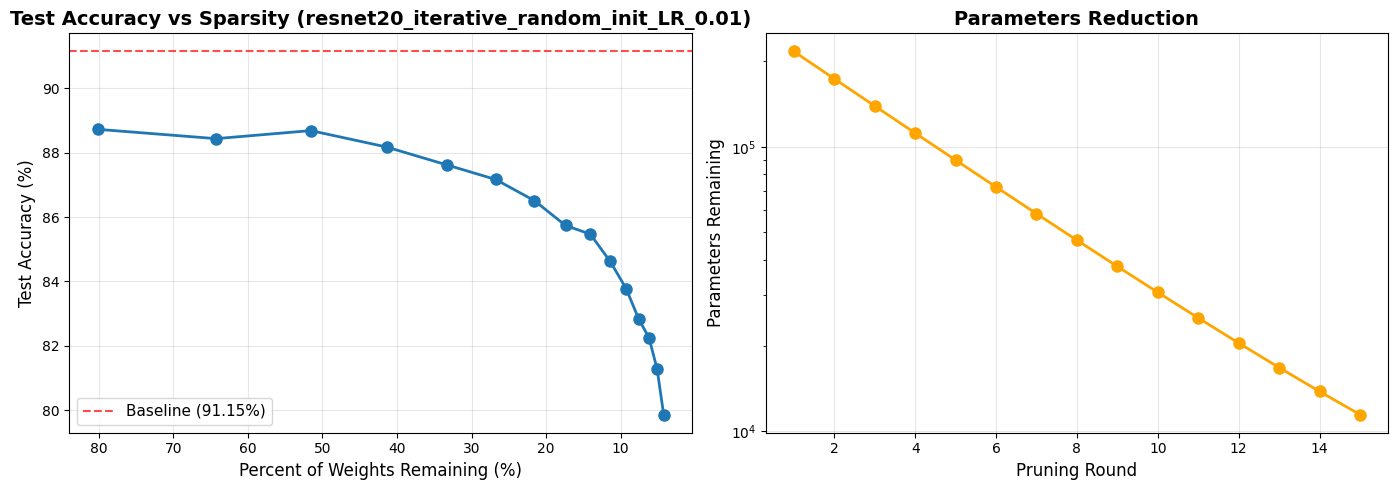

Pruning figure saved to: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/figures/Random_init_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.png


In [19]:
# --- Visualize ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)

# Robust baseline line handling (CPU/GPU compatible)
baseline_acc_val = 91.15
# baseline_acc_val = test_accuracy.item() if isinstance(test_accuracy, torch.Tensor) else test_accuracy
ax1.axhline(y=baseline_acc_val, color='r', linestyle='--', label=f'Baseline ({baseline_acc_val:.2f}%)', alpha=0.7)

ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title(f'Test Accuracy vs Sparsity ({model_name})', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis() 

# Plot 2: Params Reduction
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log') # Log scale is great for pruning

plt.tight_layout()

# Save Pruning Figure
random_init_pruning_fig_path = os.path.join(fig_dir, f"Random_init_pruning_results_{run_id}.png")
plt.savefig(random_init_pruning_fig_path, dpi=150)
plt.show()

print(f"Pruning figure saved to: {random_init_pruning_fig_path}")

In [21]:
# Identify winning tickets
baseline_accuracy = 91.15
# baseline_accuracy = test_accuracy
winning_tickets_random_init = []

for r in random_init_results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets_random_init.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets_random_init)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets_random_init:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets_random_init:
    best_ticket = min(winning_tickets_random_init, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 0 Winning Tickets!
Baseline Accuracy: 91.15%

Winning Tickets (accuracy >= 89.33%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------


正在加载数据...


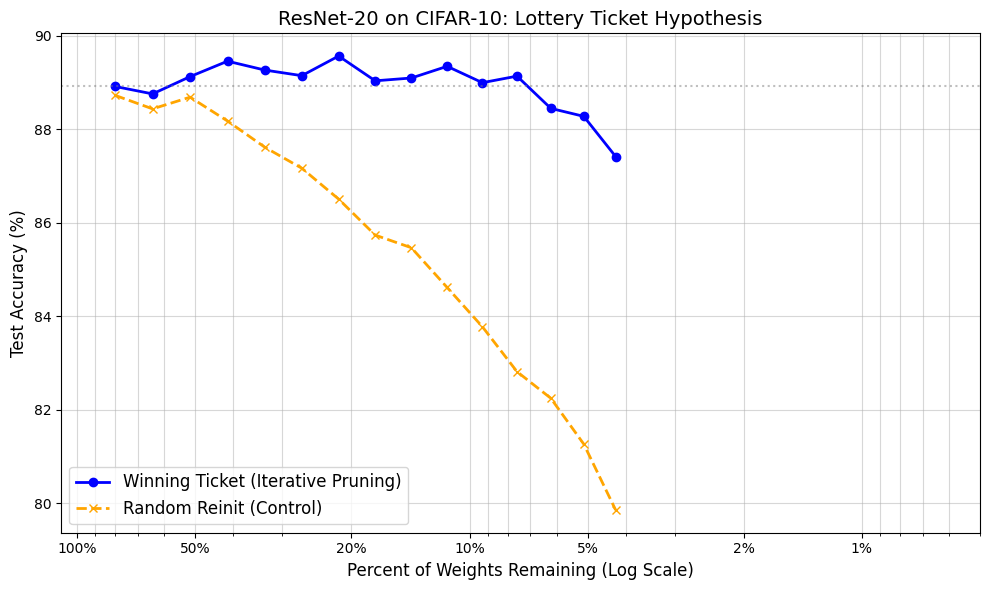

图表已保存至: ../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/figures/iterative_random_init_comparison_resnet20_iterative_random_init_LR_0.01_20260111_205802.png


In [25]:
import torch
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 定义文件路径
# ==========================================
# 这是一个相对路径，确保你的 Notebook 和 results 文件夹的相对位置是正确的
base_dir = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints"
iterative_file = "iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
random_init_file = "random_init_results_matched.pth"

iterative_path = os.path.join(base_dir, iterative_file)
random_init_path = os.path.join(base_dir, random_init_file)

# ==========================================
# 2. 加载数据
# ==========================================
if not os.path.exists(iterative_path) or not os.path.exists(random_init_path):
    print("❌ 错误：找不到文件，请检查路径是否正确！")
else:
    print("正在加载数据...")
    data_iter = torch.load(iterative_path, map_location='cpu') # 加载到 CPU 方便绘图
    data_rand = torch.load(random_init_path, map_location='cpu')
    
    # 提取结果列表
    # res_iter = data_iter['results']
    # res_rand = data_rand['results']

    res_iter = results
    res_rand = random_init_results
    
    # ==========================================
    # 3. 提取绘图数据 (X轴: 稀疏度, Y轴: 准确率)
    # ==========================================
    # Iterative Pruning (Winning Ticket)
    # 我们通常把 Base Model (100% 权重) 作为第一个点
    # 注意：你的 results 列表里可能第一项就是 Pruned 后的，
    # 如果第一轮训练前没有存 100% 的结果，我们主要看后面的趋势
    
    x_iter = [item['remaining_params_pct'] for item in res_iter]
    y_iter = [item['test_accuracy'] for item in res_iter]
    
    # Random Init (Control)
    x_rand = [item['remaining_params_pct'] for item in res_rand]
    y_rand = [item['test_accuracy'] for item in res_rand]
    
    # ==========================================
    # 4. 绘制对比图 (复现论文风格)
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # 绘制曲线
    plt.plot(x_iter, y_iter, marker='o', label='Winning Ticket (Iterative Pruning)', color='blue', linewidth=2)
    plt.plot(x_rand, y_rand, marker='x', label='Random Reinit (Control)', color='orange', linestyle='--', linewidth=2)
    
    # 设置 X 轴为对数坐标 (论文通常这样做，因为后期稀疏度变化很小但影响很大)
    plt.xscale('log')
    
    # 反转 X 轴 (让 100% 在左边，0.1% 在右边，符合阅读习惯)
    plt.xlim(110, 0.5)  # 范围从 110% 到 0.5% (根据你的数据调整)
    
    # 设置刻度标签，让它显示为正常的百分比数字
    plt.xticks([100, 50, 20, 10, 5, 2, 1], ['100%', '50%', '20%', '10%', '5%', '2%', '1%'])
    
    # 添加标签和标题
    plt.title('ResNet-20 on CIFAR-10: Lottery Ticket Hypothesis', fontsize=14)
    plt.xlabel('Percent of Weights Remaining (Log Scale)', fontsize=12)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend(fontsize=12)
    
    # 添加辅助线 (可选，标出 Baseline 精度)
    baseline_acc = y_iter[0] 
    plt.axhline(y=baseline_acc, color='gray', linestyle=':', alpha=0.5, label='Baseline Accuracy')
    
    plt.tight_layout()
    
    # 保存图片
    # random_init_pruning_fig_path = os.path.join(fig_dir, f"Random_init_pruning_results_{run_id}.png")
    save_comparison_fig_path = os.path.join(fig_dir, f"iterative_random_init_comparison_{run_id}.png") # 假设有个 figures 文件夹
    # os.makedirs(save_fig_path, exist_ok=True)
    plt.savefig(save_comparison_fig_path, dpi=150)
    
    plt.show()
    
    print(f"图表已保存至: {save_comparison_fig_path}")

## 6. Analyze Results

### 6.1 Iterative Pruning

Visualize and analyze the pruning results.

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

## 8. Save Results

In [ ]:
# import json
# import numpy as np

# # Helper to convert non-serializable types
# def json_serializer(obj):
#     if isinstance(obj, (np.float32, np.float64)):
#         return float(obj)
#     if isinstance(obj, (np.int32, np.int64)):
#         return int(obj)
#     if isinstance(obj, torch.Tensor):
#         return obj.item()
#     raise TypeError(f"Type {type(obj)} not serializable")

# # Prepare Dictionary
# results_dict = {
#     'run_id': run_id,
#     'timestamp': timestamp,
#     'model': model_name,
#     'dataset': 'CIFAR-10',
#     'baseline_accuracy': baseline_acc_val,
#     'optimizer': optimizer_name,
#     'epochs_per_round': epochs, # Assuming variable name used in loop
#     'pruning_config': pruning_config,
#     'pruning_results': results,
#     'winning_tickets': winning_tickets # Uncomment if you implemented finding tickets logic
# }

# # Save JSON
# json_path = os.path.join(run_dir, f"experiment_data_{run_id}.json")

# with open(json_path, 'w') as f:
#     json.dump(results_dict, f, indent=2, default=json_serializer)

# print(f"Full results saved to: {json_path}")


In [ ]:
# import os
# import json
# import numpy as np

# # 1. 安全过滤函数：移除包含大 Tensor 的 'mask' 字段
# def filter_masks(data_list):
#     clean_list = []
#     for item in data_list:
#         # 复制字典，排除 'mask' 键
#         clean_item = {k: v for k, v in item.items() if k != 'mask'}
#         clean_list.append(clean_item)
#     return clean_list

# # 2. 准备干净的数据
# # 务必对 pruning_results 和 winning_tickets 都做清理
# results_clean = filter_masks(results)
# winning_tickets_clean = filter_masks(winning_tickets)

# # 3. 准备字典
# results_dict = {
#     'run_id': run_id,
#     'timestamp': timestamp,
#     'model': model_name,
#     'dataset': 'CIFAR-10',
#     'baseline_accuracy': baseline_acc_val,
#     'optimizer': optimizer_name,  # 确保你有定义这个变量，或者写 "SGD"
#     'epochs_per_round': 86,       # 或者用变量 epochs
#     'pruning_config': pruning_config if 'pruning_config' in locals() else "One-Shot Global",
#     'pruning_results': results_clean,       # <--- 使用过滤后的数据
#     'winning_tickets': winning_tickets_clean # <--- 使用过滤后的数据
# }

# # 4. JSON 序列化辅助函数 (保持不变)
# def json_serializer(obj):
#     if isinstance(obj, (np.float32, np.float64)):
#         return float(obj)
#     if isinstance(obj, (np.int32, np.int64)):
#         return int(obj)
#     if isinstance(obj, torch.Tensor):
#         # 这里的容错性更好：如果是标量就转，如果是向量就转 list
#         if obj.numel() == 1:
#             return obj.item()
#         else:
#             return obj.tolist() # 以防万一还有其他 Tensor 列表
#     raise TypeError(f"Type {type(obj)} not serializable")

# # 5. 保存
# json_path = os.path.join(run_dir, f"experiment_data_{run_id}.json")

# with open(json_path, 'w') as f:
#     json.dump(results_dict, f, indent=2, default=json_serializer)

# print(f"✅ Full results (without heavy masks) saved to: {json_path}")

✅ Full results (without heavy masks) saved to: ../../results/resnet20_one_shot_original_init_20260110_215316/experiment_data_resnet20_one_shot_original_init_20260110_215316.json


## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?